# Build a Regular RAG Document Ingestion Pipeline
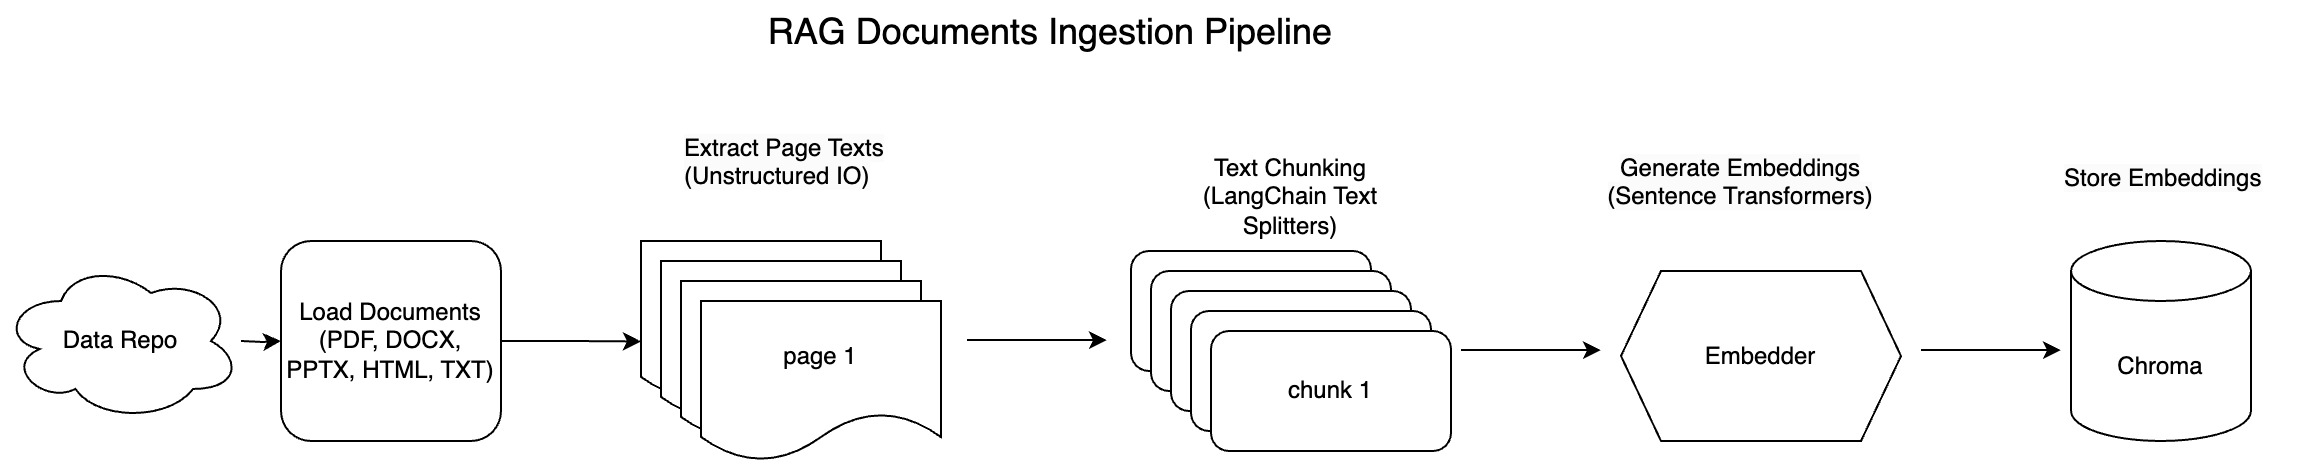

In [1]:
import os
import re
import shutil
import certifi
from typing import List, Dict
from pathlib import Path  
import uuid

# Ensure OCR binary is discoverable in notebook kernels on macOS.
os.environ["PATH"] = f"/opt/homebrew/bin:{os.environ.get('PATH', '')}"

# Ensure Python/urllib SSL uses a valid CA bundle for model downloads.
os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()

# Importing our document partitioner from unstructured.io
from unstructured.partition.auto import partition, dependency_exists
import unstructured_pytesseract.pytesseract as upyt

upyt.tesseract_cmd = shutil.which("tesseract") or "/opt/homebrew/bin/tesseract"

# If dependencies were installed after kernel start, clear cached checks.
dependency_exists.cache_clear()

In [2]:
def process_documents_pages(source_dir: str) -> List[Dict]:
    """
    Load documents from a given directory using Unstructured IO and group text by page number.

    Args:
        source_dir (str): Directory containing documents.

    Returns:
        List[Dict]: A list of dictionaries where each dictionary contains:
                    - 'text': combined text from a page,
                    - 'source': file path,
                    - 'file_name': file name with extension,
                    - 'file_type': file extension,
                    - 'page_number': page number,
                    - 'doc_id': a unique id for the entire file.
    """
    pages = []
    for file_path in Path(source_dir).rglob('*'):
        if file_path.suffix.lower() in ('.pdf', '.docx', '.pptx', '.html', '.txt'):
            print("processing file:", file_path)
            elements = partition(str(file_path))
            doc_id = str(uuid.uuid4())  # Single doc_id per file

            # Group text by page number
            page_texts = {}
            for el in elements:
                # Get the page number; default to 1 if not provided
                page_number = getattr(el.metadata, "page_number", None)
                page_number = int(page_number) if page_number is not None else 1
                
                # Append element text to the corresponding page's list
                page_texts.setdefault(page_number, []).append(str(el))
            
            # Create a document entry for each page
            for page_number, texts in page_texts.items():
                combined_text = " ".join(texts).strip()
                pages.append({
                    "text": combined_text,
                    "source": str(file_path),
                    "file_name": file_path.name,
                    "file_type": file_path.suffix,
                    "page_number": page_number,
                    "doc_id": doc_id
                })
    return pages

In [3]:
source_directory = "documents" 
pages = process_documents_pages(source_directory)

for page in pages:
    print(f"File Name: {page['file_name']}")
    print(f"Page Number: {page['page_number']}")
    print(f"Text: {page['text'][:200]}...")  # Truncate text to 100 characters
    print("-" * 80)  # Separator for readability

processing file: documents/vallor_rewack_IntroToDataEthics.pdf


No languages specified, defaulting to English.


processing file: documents/inie et al 2025.pdf


No languages specified, defaulting to English.
Ignoring wrong pointing object 9 0 (offset 0)
Cannot set non-stroke color because expected 4 components but got [0, 0, 0]
Cannot set non-stroke color because expected 4 components but got [0, 0, 0]
Cannot set non-stroke color because expected 4 components but got [0, 0, 0]
Cannot set non-stroke color because expected 4 components but got [0, 0, 0]


processing file: documents/data feminism ch 7 show your work.pdf


...

processing file: documents/Bender, Friedman - 2018 - Data Statements for NLP Toward Mitigating System Bias and Enabling Better Science.pdf


No languages specified, defaulting to English.
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]


processing file: documents/aragon hcds 2020 ch 1 excerpt.pdf


Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set stroke color because expected 4 components but got [0]
Cannot set stroke color because expected 4 components but got [1]
Cannot set stroke color because expected 4 components but got [0]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set stroke color because expected 4 components but got [0]
Cannot set stroke color because expected 4 components but got [1]
Cannot set stroke color because expected 4 components but got [0]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected

File Name: vallor_rewack_IntroToDataEthics.pdf
Page Number: 1
Text: An Introduction to Data Ethics MODULE AUTHOR:1 Shannon Vallor, Ph.D. William J. Rewak, S.J. Professor of Philosophy, Santa Clara University TABLE OF CONTENTS Introduction PART ONE: What ethically sign...
--------------------------------------------------------------------------------
File Name: vallor_rewack_IntroToDataEthics.pdf
Page Number: 2
Text: An Introduction to Data Ethics MODULE AUTHOR: Shannon Vallor, Ph.D. William J. Rewak, S.J. Professor of Philosophy, Santa Clara University 1. What do we mean when we talk about ‘ethics’? Ethics in the...
--------------------------------------------------------------------------------
File Name: vallor_rewack_IntroToDataEthics.pdf
Page Number: 3
Text: make it easier for people to live well (for example, by allowing more efficient use and distribution of essential resources for a good life, such as food, water, energy, or medical care). Poorly desig...
----------------------

## Chunking Strategies

This section demonstrates various strategies to divide a document into smaller, manageable text chunks using specialized text splitters. ChunkingStrategy class allow users to split text into smaller chunks using either a "fixed" or "recursive" method, with configurable parameters like encoding type, chunk size, and overlap.

In [5]:
## doc: https://python.langchain.com/v0.1/docs/modules/data_connection/document_transformers/

from typing import List
# Importing various text splitters for different chunking strategies
from langchain_text_splitters import (
    RecursiveCharacterTextSplitter,
    CharacterTextSplitter
)

class ChunkingStrategy:
    def __init__(self, method: str = 'recursive', encoding_name: str = "cl100k_base", 
                 chunk_size: int = 300, chunk_overlap: int = 50):
        """
        Initialize a chunking strategy.

        Args:
            method (str): The chunking method, e.g. 'fixed' or 'recursive'.
            encoding_name (str): The name of the encoding to use.
            chunk_size (int): The size of each chunk.
            chunk_overlap (int): The overlap between chunks.
        """
        self.method = method
        self.encoding_name = encoding_name
        self.chunk_size = chunk_size
        self.chunk_overlap = chunk_overlap

    def chunk_document(self, text: str) -> List[str]:
        """
        Chunk a document's text using the selected strategy.

        Args:
            text (str): The document's text to chunk.

        Returns:
            List[str]: A list of text chunks.
        """
        if self.method == 'fixed':
            splitter = CharacterTextSplitter.from_tiktoken_encoder(
                encoding_name=self.encoding_name, 
                chunk_size=self.chunk_size, 
                chunk_overlap=self.chunk_overlap
            )
            return splitter.split_text(text)
        elif self.method == 'recursive':
            splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
                encoding_name=self.encoding_name, 
                chunk_size=self.chunk_size, 
                chunk_overlap=self.chunk_overlap
            )
            return splitter.split_text(text)
        else:
            raise ValueError("Unknown chunking method: choose 'fixed' or 'recursive'.")

/Volumes/D/Jobs/Projects/Ray_WS/Distributed_RAG_Pipeline/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Test the Chunking Strategy Implementation

Now let's put the chunking process in action for a single page:

In [7]:

# Create a ChunkingStrategy instance with the desired settings.
chunker = ChunkingStrategy(chunk_size=300, chunk_overlap=50)

# Retrieve page information from the pages list (using the 11th page as an example).
page = pages[10]
file_name = page["file_name"]
file_type = page["file_type"]
page_number = page["page_number"]
text_content = page["text"]

# Debug: Print the text content of the selected page.
print("Debug - Page Text:", text_content)

# Chunk the document text using the chunk_document method.
chunks = chunker.chunk_document(text_content)

# Display file and page details along with the number of chunks generated.
print(f"File: {file_name} (Page Number: {page_number})")
print(f"Number of chunks: {len(chunks)}")
print("-" * 80)

# Iterate through each chunk and print its contents.
for idx, chunk in enumerate(chunks):
    print(f"Chunk {idx + 1}:")
    print(chunk)
    print("-" * 80)

Debug - Page Text: we’ll discuss the specific challenges that avoiding privacy harms presents for data practitioners, and explore possible tools and solutions. 2. HARMS TO FAIRNESS AND JUSTICE: We all have a significant life interest in being judged and treated fairly, whether it involves how we are treated by law enforcement and the criminal and civil court systems, how we are evaluated by our employers and teachers, the quality of health care and other services we receive, or how financial institutions and insurers treat us. All of these systems are being radically transformed by new data practices and analytics, and the preliminary evidence suggests that the values of fairness and justice are too often endangered by poor design and use of such practices. The most common causes of such harms are: arbitrariness; avoidable errors and inaccuracies; and unjust and often hidden biases in datasets and data practices. For example, investigative journalists have found compelling evidence of 

ImportError: Could not import tiktoken python package. This is needed in order to calculate max_tokens_for_prompt. Please install it with `pip install tiktoken`.